# E_S3.1 — Synthetic Data Preview & Human Annotation

Preview scatter plots for all families × SNR levels, with human annotation of
the visually identifiable shape at each signal-to-noise level.

Three concepts are kept separate: **family truth** (the generating geometry),
**visible label** (what remains identifiable at the current SNR), and
**classifier group** (the coarser label supported by the current CaseA tree).

- **Rows**: families (F01–F26)
- **Columns**: representative SNR levels (∞ → 0.001)
- **Color-coded annotation** on each subplot:
  - Green = matches family truth
  - Amber = acceptable alternative (also_ok)
  - Purple = Uncertain (signal present but shape ambiguous)
  - Gray = No Global Relationship (noise)
  - Red = different from expected

Edit `HUMAN_LABELS` below to refine annotations.

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError

REPO_ROOT = locate_repo_root()
SPREAD = 'constant'
GROUP = 'selected'
XDIST = 'even'
INPUT_DIR = REPO_ROOT / 'F' / 'output' / 'E' / 'E_S1' / SPREAD / GROUP / XDIST
print(f'Data: {INPUT_DIR.relative_to(REPO_ROOT)}')

Data: F/output/E/E_S1/constant/selected/even


## 1 — Family catalogue & human annotation

**`HUMAN_LABELS`**: for each family, define SNR thresholds where the
visually identifiable label changes. Checked top-to-bottom; first match
(snr >= threshold) wins.

`truth` is never changed by SNR. These are initial visible-label annotations
based on visual inspection of variant=strong.
Adjust after viewing the plots — especially for mild/standard variants
where shapes are weaker.

In [2]:
FAMILY_CATALOGUE = {
    'F01': {'name': 'Linear pos',       'truth': 'Linear',            'classifier_group': 'Linear',       'also_ok': ['Near-linear']},
    'F03': {'name': 'Power convex pos', 'truth': 'Acceleration',      'classifier_group': 'Acceleration', 'also_ok': ['Near-linear']},
    'F05': {'name': 'Power concave pos','truth': 'Saturation',        'classifier_group': 'Saturation',   'also_ok': ['Near-linear']},
    'F07': {'name': 'Saturation pos',   'truth': 'Saturation',        'classifier_group': 'Saturation',   'also_ok': ['Near-linear']},
    'F13': {'name': 'S-curve pos',      'truth': 'S-curve',           'classifier_group': 'Complex',      'also_ok': []},
    'F15': {'name': 'Threshold pos',    'truth': 'Threshold',         'classifier_group': 'Complex',      'also_ok': []},
    'F18': {'name': 'Quadratic U',      'truth': 'U-shape',           'classifier_group': 'U-shape',      'also_ok': []},
    'F19': {'name': 'Spike',            'truth': 'Spike',             'classifier_group': 'Complex',      'also_ok': []},
    'F21': {'name': 'Cubic',            'truth': 'Cubic',             'classifier_group': 'Cubic',        'also_ok': []},
    'F22': {'name': 'Oscillation',      'truth': 'Oscillation',       'classifier_group': 'Oscillation',  'also_ok': ['Complex']},
    'F23': {'name': 'Two Lines',        'truth': 'Branch',            'classifier_group': 'Branch',       'also_ok': ['Candidate branch']},
    'F24': {'name': 'Line+Parabola',    'truth': 'Branch',            'classifier_group': 'Branch',       'also_ok': ['Candidate branch']},
    'F25': {'name': 'Multi-regime',     'truth': 'Multi-regime',      'classifier_group': 'Complex',      'also_ok': ['Complex']},
    'F26': {'name': 'Windowed thresh',  'truth': 'Windowed response', 'classifier_group': 'Complex',      'also_ok': ['Complex']},
    'Null': {'name': 'No relationship','truth': 'No Global Relationship', 'classifier_group': 'No Global Relationship', 'also_ok': []},
}
TRUTH_MAP = {f: v['truth'] for f, v in FAMILY_CATALOGUE.items()}
CLASSIFIER_GROUP_MAP = {f: v['classifier_group'] for f, v in FAMILY_CATALOGUE.items()}
ALSO_OK_MAP  = {f: v['also_ok']  for f, v in FAMILY_CATALOGUE.items()}

# ═══════════════════════════════════════════════════════════════════
# HUMAN LABELS — edit these to refine annotations
# Format: family_id → [(min_snr, label), ...]
# Checked top-to-bottom; first (snr >= threshold) wins.
# "Uncertain" = signal present but shape ambiguous.
# Based on visual inspection of variant=strong.
# ═══════════════════════════════════════════════════════════════════

HUMAN_LABELS = {
    # ── Monotonic families ──
    'F01': [  # Linear — trend visible until ~0.3
        (0.3, 'Linear'),
        (0.1, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F03': [  # Acceleration — retain the family label only while curvature is visible
        (5,   'Acceleration'),
        (0.5, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F05': [  # Saturation (power concave)
        (5,   'Saturation'),
        (0.5, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F07': [  # Saturation — plateau remains visible at moderate SNR
        (2,   'Saturation'),
        (0.5, 'Near-linear'),
        (0.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F13': [  # Sigmoid: acceleration then deceleration, not one-sided saturation
        (5,   'S-curve'),
        (0.5, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F15': [  # Abrupt step/threshold, not saturation
        (5,   'Threshold'),
        (0.5, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    # ── Non-monotonic families ──
    'F18': [  # Quadratic U — clear ≥1
        (1,   'U-shape'),
        (0.3, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F19': [  # Local spike is distinct from a broad U-shape
        (0.5, 'Spike'),
        (0.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F21': [  # Cubic only while both turns remain identifiable
        (5,   'Cubic'),
        (0.5, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F22': [  # Periodic multi-cycle signal
        (2,   'Oscillation'),
        (0.5, 'Complex'),
        (0.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    # ── Branch families ──
    'F23': [  # Two lines: retain weak but visible forks as candidates
        (5,   'Branch'),
        (2,   'Candidate branch'),
        (1.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F24': [  # Line+parabola: a partial fork remains a candidate
        (2,   'Branch'),
        (1.5, 'Candidate branch'),
        (1.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F25': [  # Segmented regimes, not a persistent conditional fork
        (2,   'Multi-regime'),
        (0.5, 'Complex'),
        (0.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'F26': [  # Repeated localized windows are not periodic oscillation
        (2,   'Windowed response'),
        (0.5, 'Complex'),
        (0.2, 'Uncertain'),
        (0,   'No Global Relationship'),
    ],
    'Null': [
        (0,   'No Global Relationship'),
    ],
}


def get_human_label(fid, snr):
    if fid not in HUMAN_LABELS:
        return TRUTH_MAP.get(fid, '?')
    snr_val = snr if np.isfinite(snr) else 1e10
    for threshold, label in HUMAN_LABELS[fid]:
        if snr_val >= threshold:
            return label
    return 'No Global Relationship'


# Abbreviated display names for plot labels
SHORT_LABEL = {
    'No Global Relationship': 'No Global',
    'Acceleration': 'Accel',
    'Near-linear': 'Near-lin',
    'Oscillation': 'Oscill',
    'Candidate branch': 'Candidate',
    'Windowed response': 'Windowed',
}

def short(label):
    return SHORT_LABEL.get(label, label)


# Representative SNR levels to display (~11 log-spaced)
TARGET_SNRS = [np.inf, 100, 30, 10, 3, 1, 0.3, 0.1, 0.03, 0.01, 0.001]

print(f'{len(FAMILY_CATALOGUE)} families, {len(TARGET_SNRS)} target SNR levels')

15 families, 11 target SNR levels


## 2 — Load data

In [3]:
cases_df = pd.read_csv(INPUT_DIR / 'cases.csv', low_memory=False)
pts = np.load(INPUT_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']
del pts

cases_df['_pt_idx'] = pd.to_numeric(
    cases_df['candidate_index'], errors='raise'
).astype(np.int64)
cases_df = cases_df[cases_df['repeat'] == 1].reset_index(drop=True)

# Find nearest available SNR for each target
available_snrs = sorted(cases_df['nominal_snr'].dropna().unique())

def nearest_snr(target, pool):
    if not np.isfinite(target):
        infs = [s for s in pool if np.isinf(s)]
        return infs[0] if infs else max(pool)
    finite = [s for s in pool if np.isfinite(s) and s > 0]
    return min(finite, key=lambda s: abs(
        np.log10(s) - np.log10(max(target, 1e-12))
    ))

DISPLAY_SNRS = [nearest_snr(t, available_snrs) for t in TARGET_SNRS]
seen = set()
DISPLAY_SNRS = [s for s in DISPLAY_SNRS if not (s in seen or seen.add(s))]

print(f'Loaded {len(cases_df):,} cases (repeat=1)')
print(f'Variants: {sorted(cases_df["variant_level"].unique())}')
print(f'\nDisplay SNRs ({len(DISPLAY_SNRS)}):')
for s in DISPLAY_SNRS:
    print(f'  {"inf" if np.isinf(s) else f"{s:.4g}"}')

Loaded 9,535 cases (repeat=1)
Variants: ['mild', 'none', 'standard', 'strong']

Display SNRs (11):
  inf
  100
  29.35
  10.22
  2.919
  1.016
  0.2903
  0.1011
  0.03084
  0.01005
  0.001


## 3 — Scatter plot grids

One figure per variant (strong / standard / mild).
Each subplot is annotated with the human label, color-coded:
- **Green**: matches expected
- **Amber**: acceptable alternative (also_ok)
- **Gray**: No Global Relationship
- **Red**: different from expected

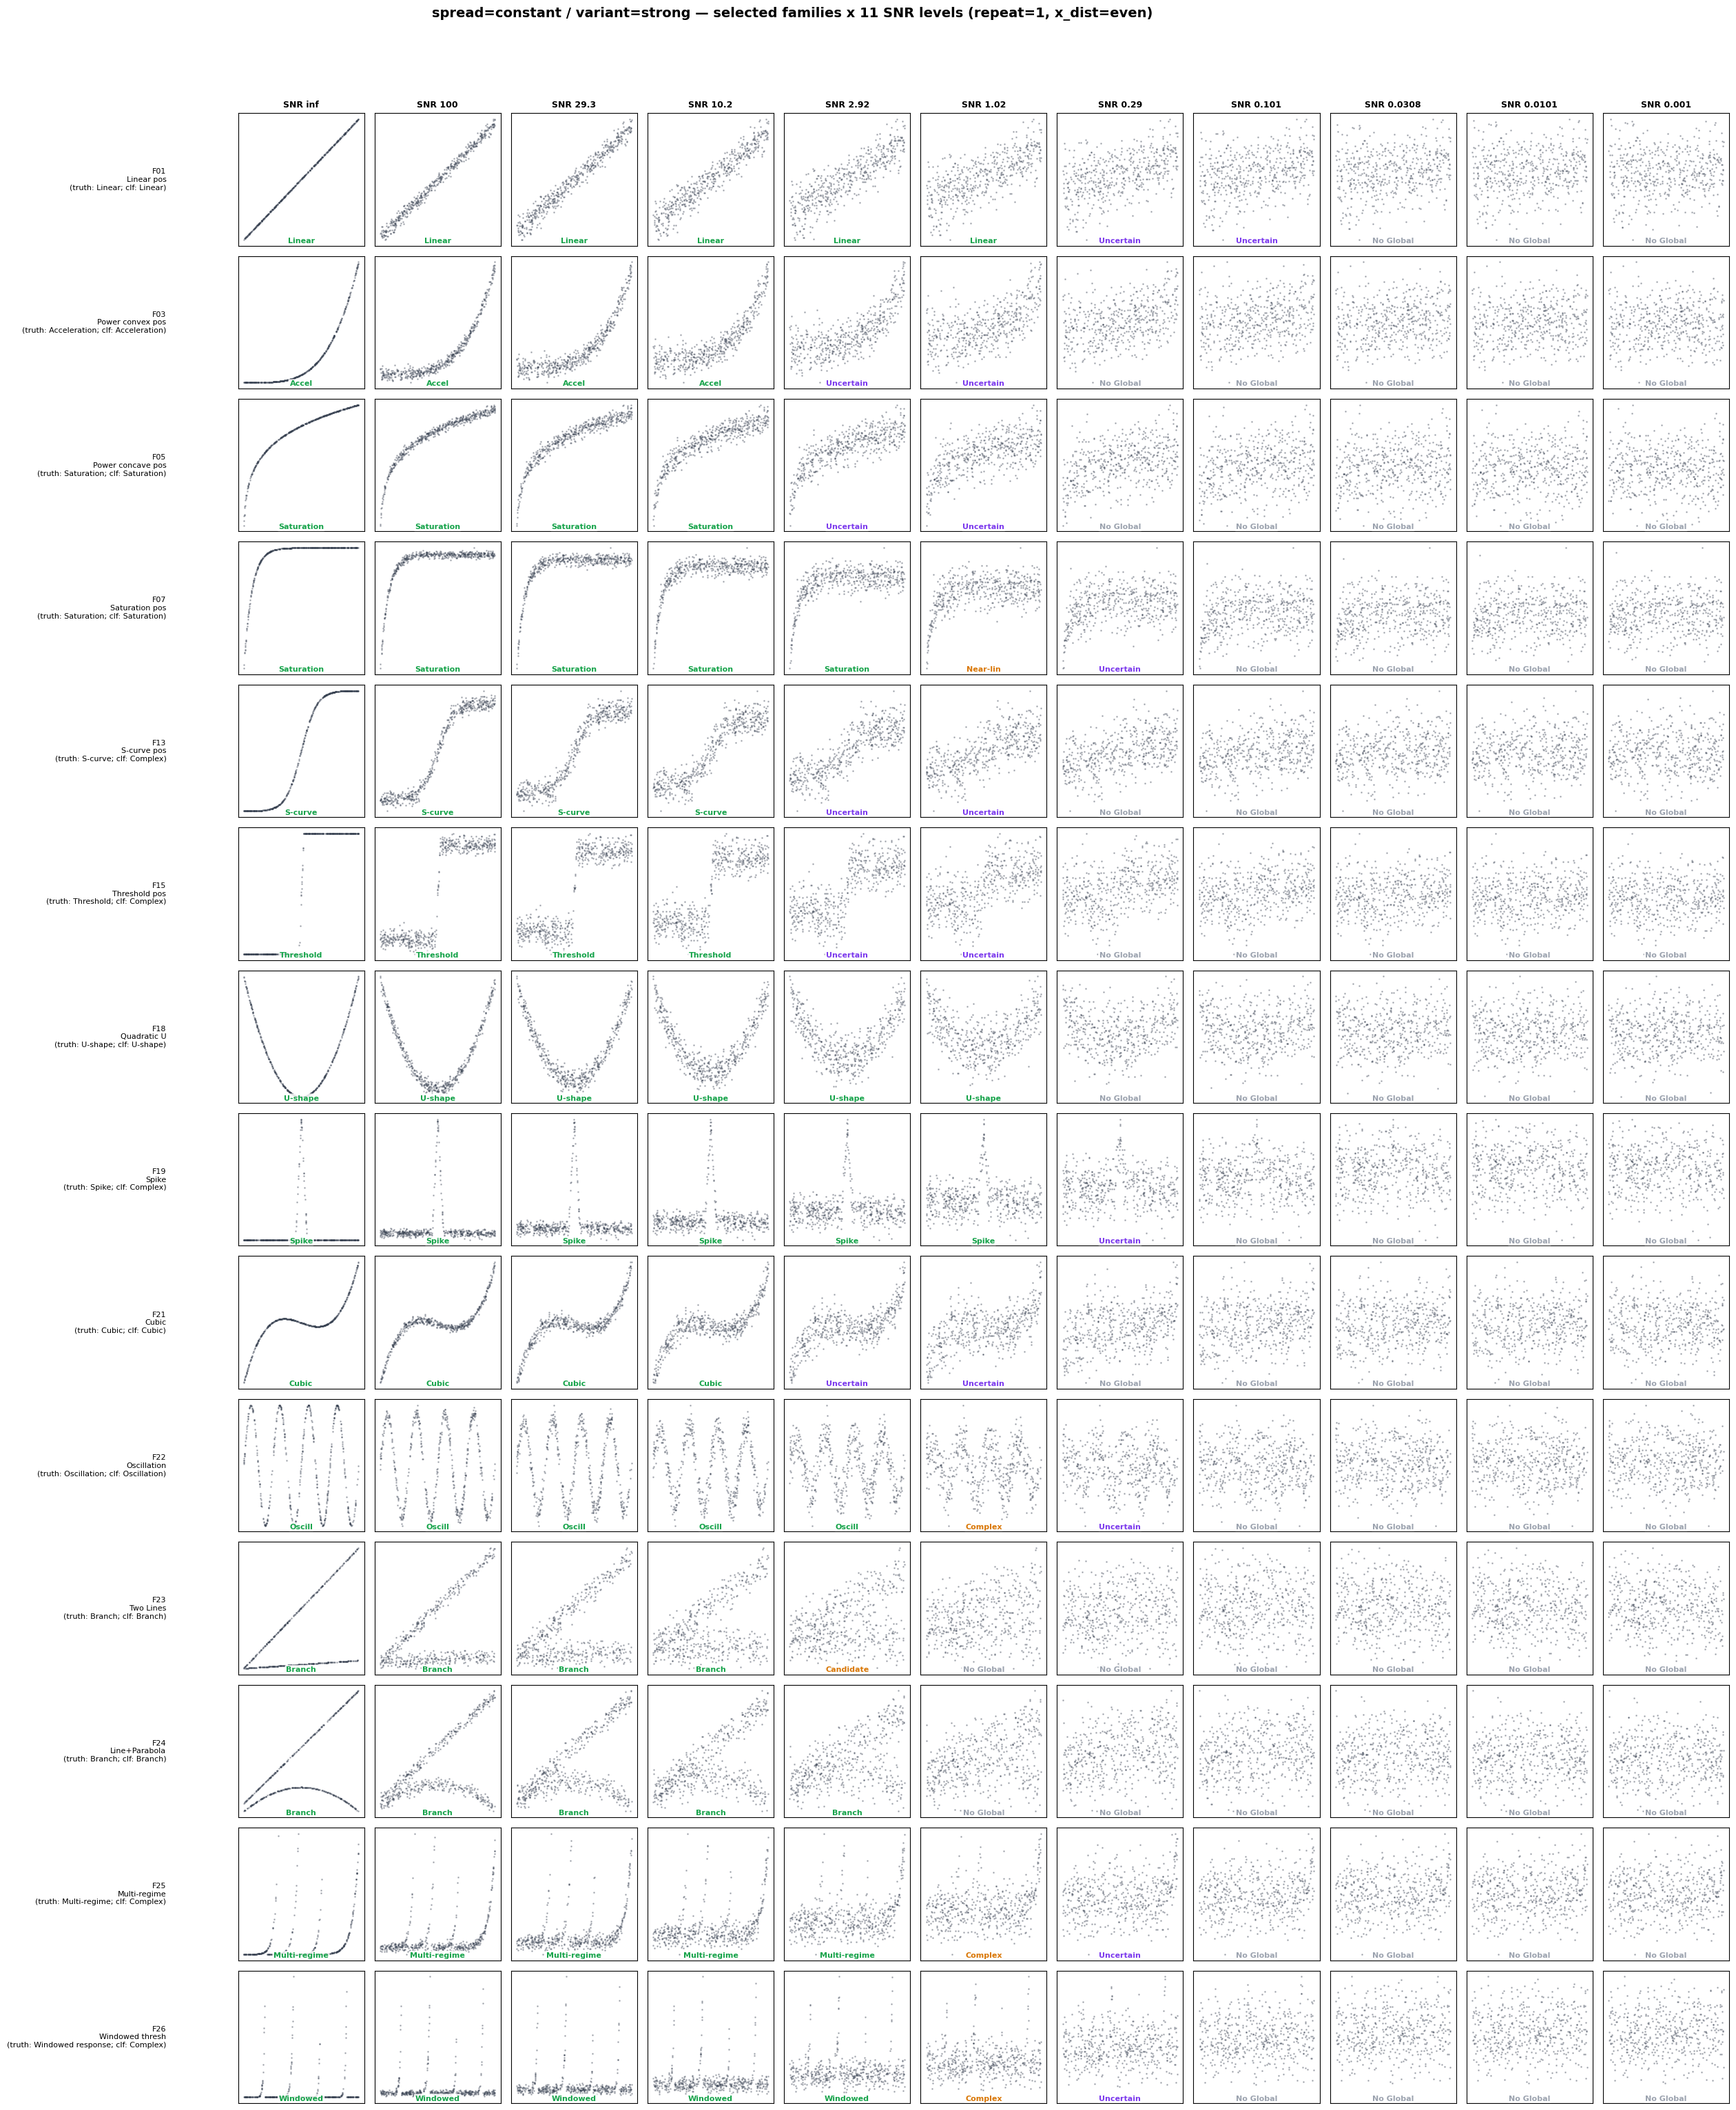

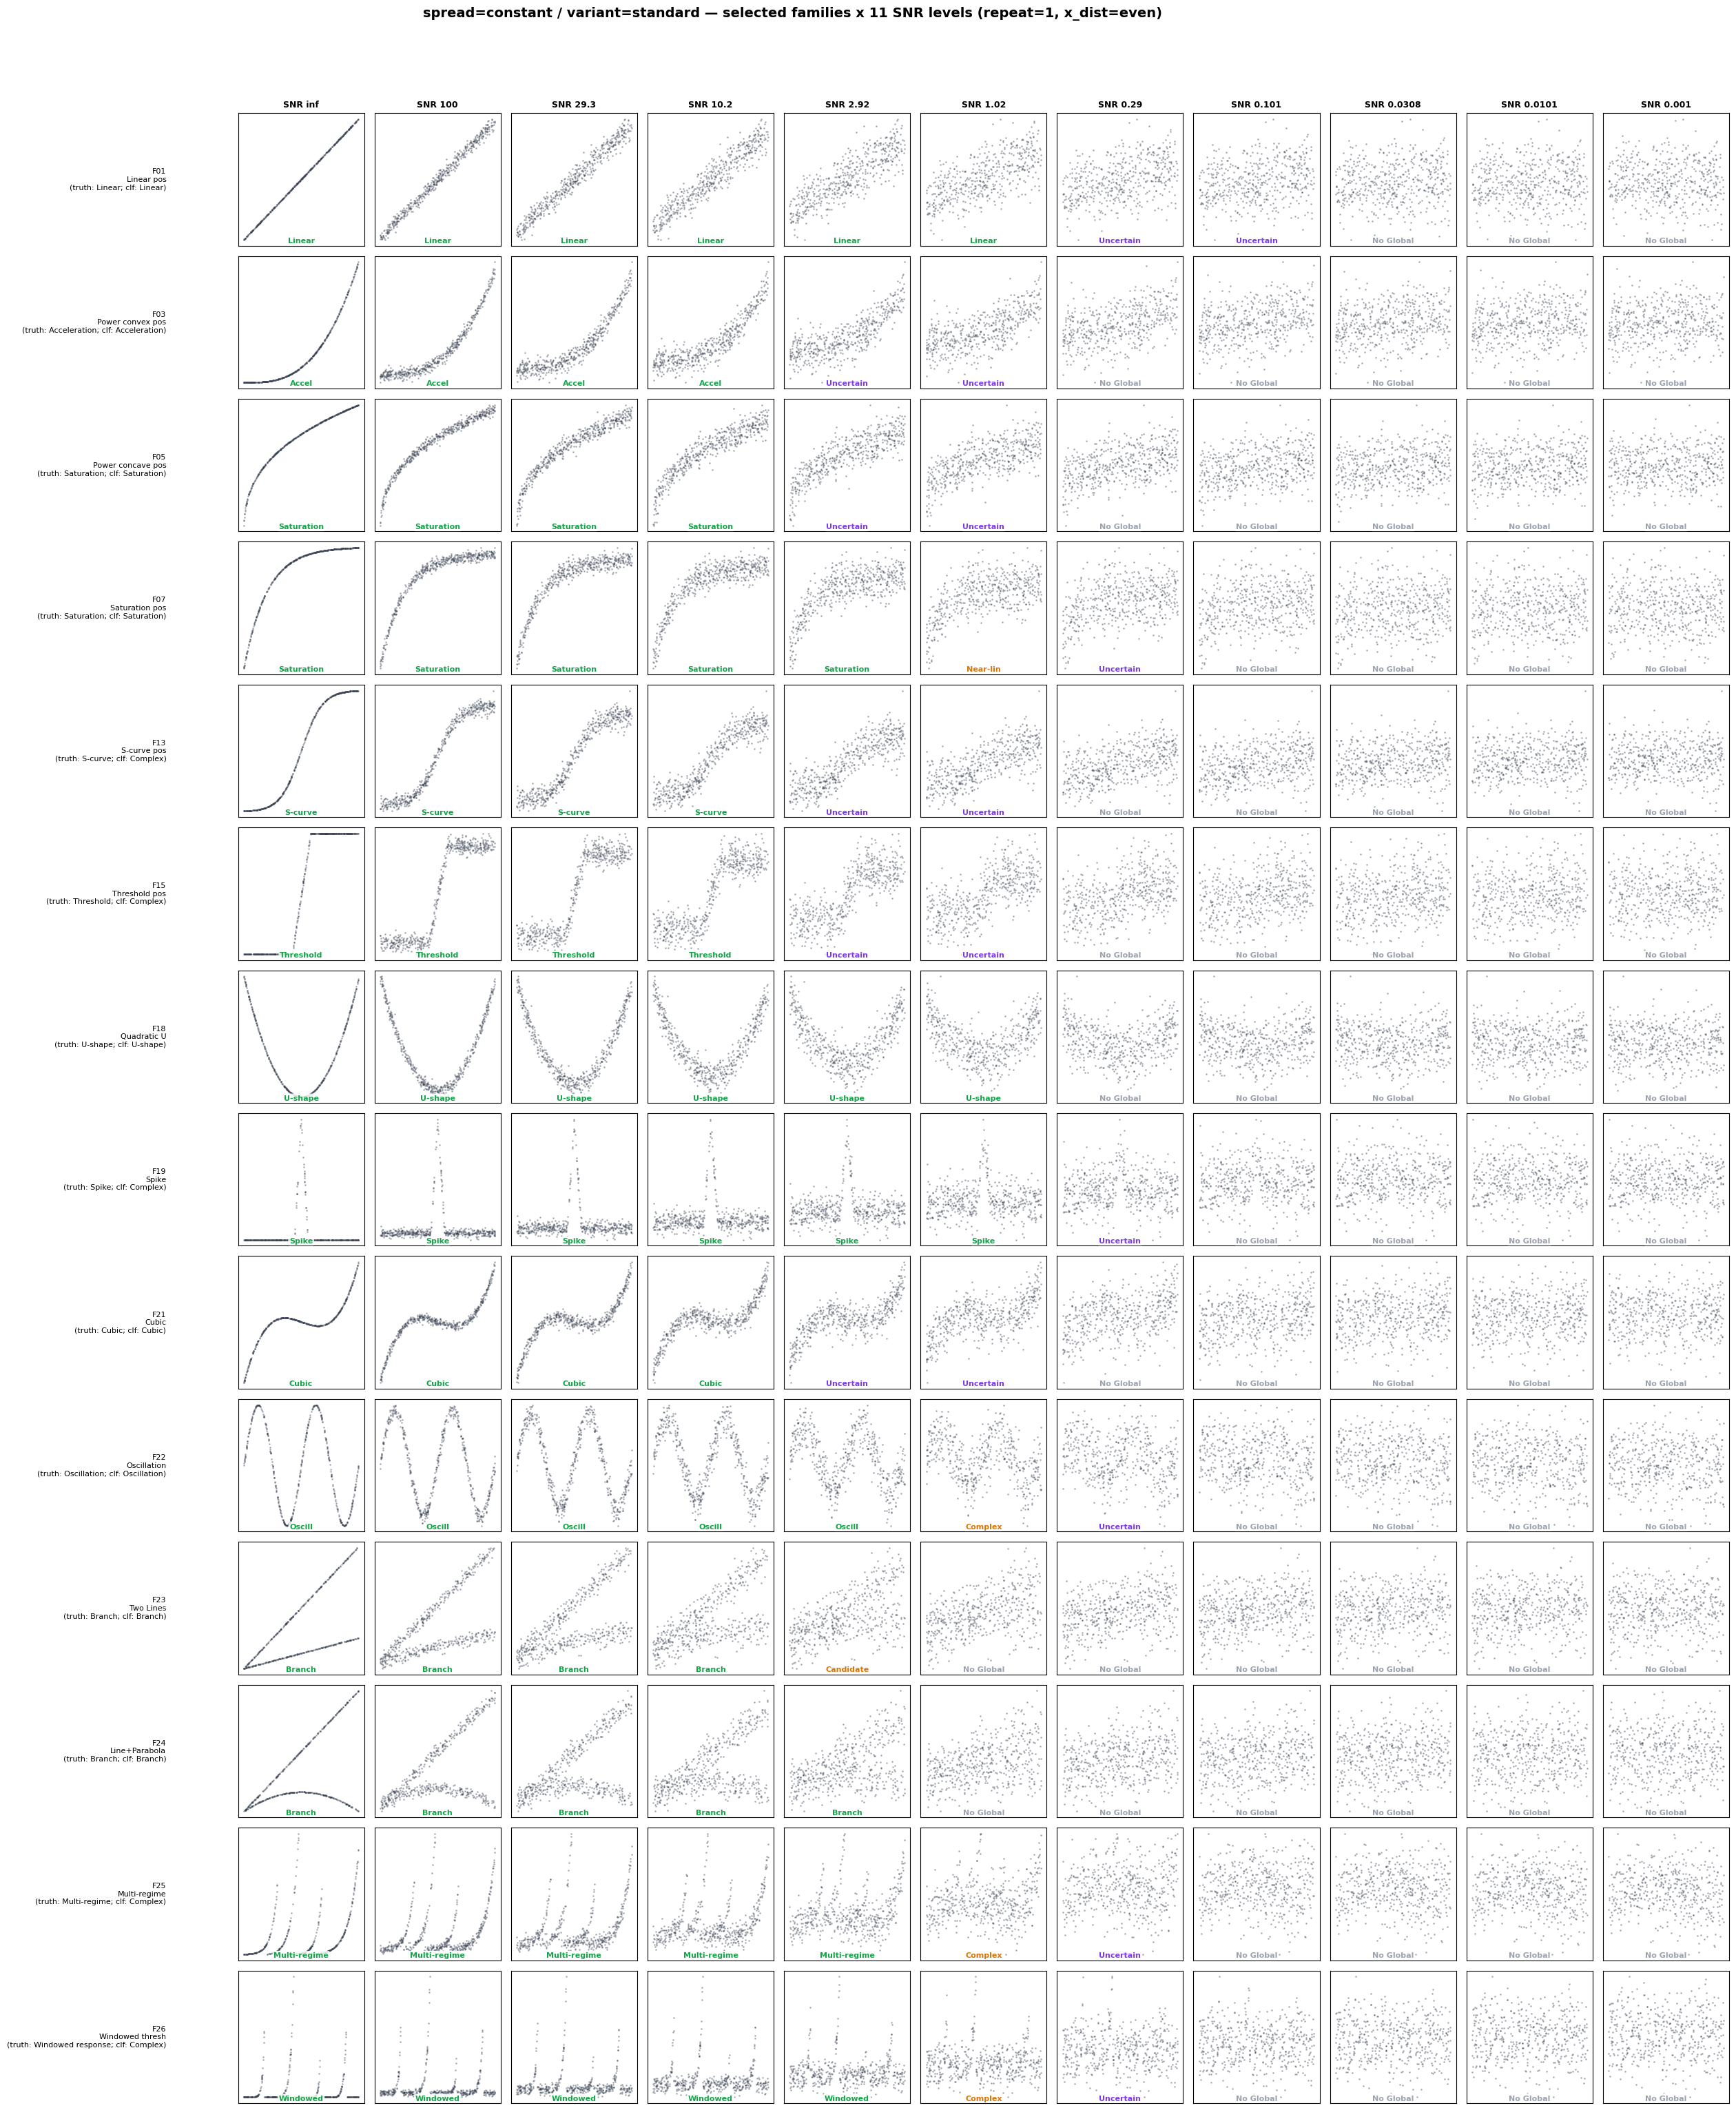

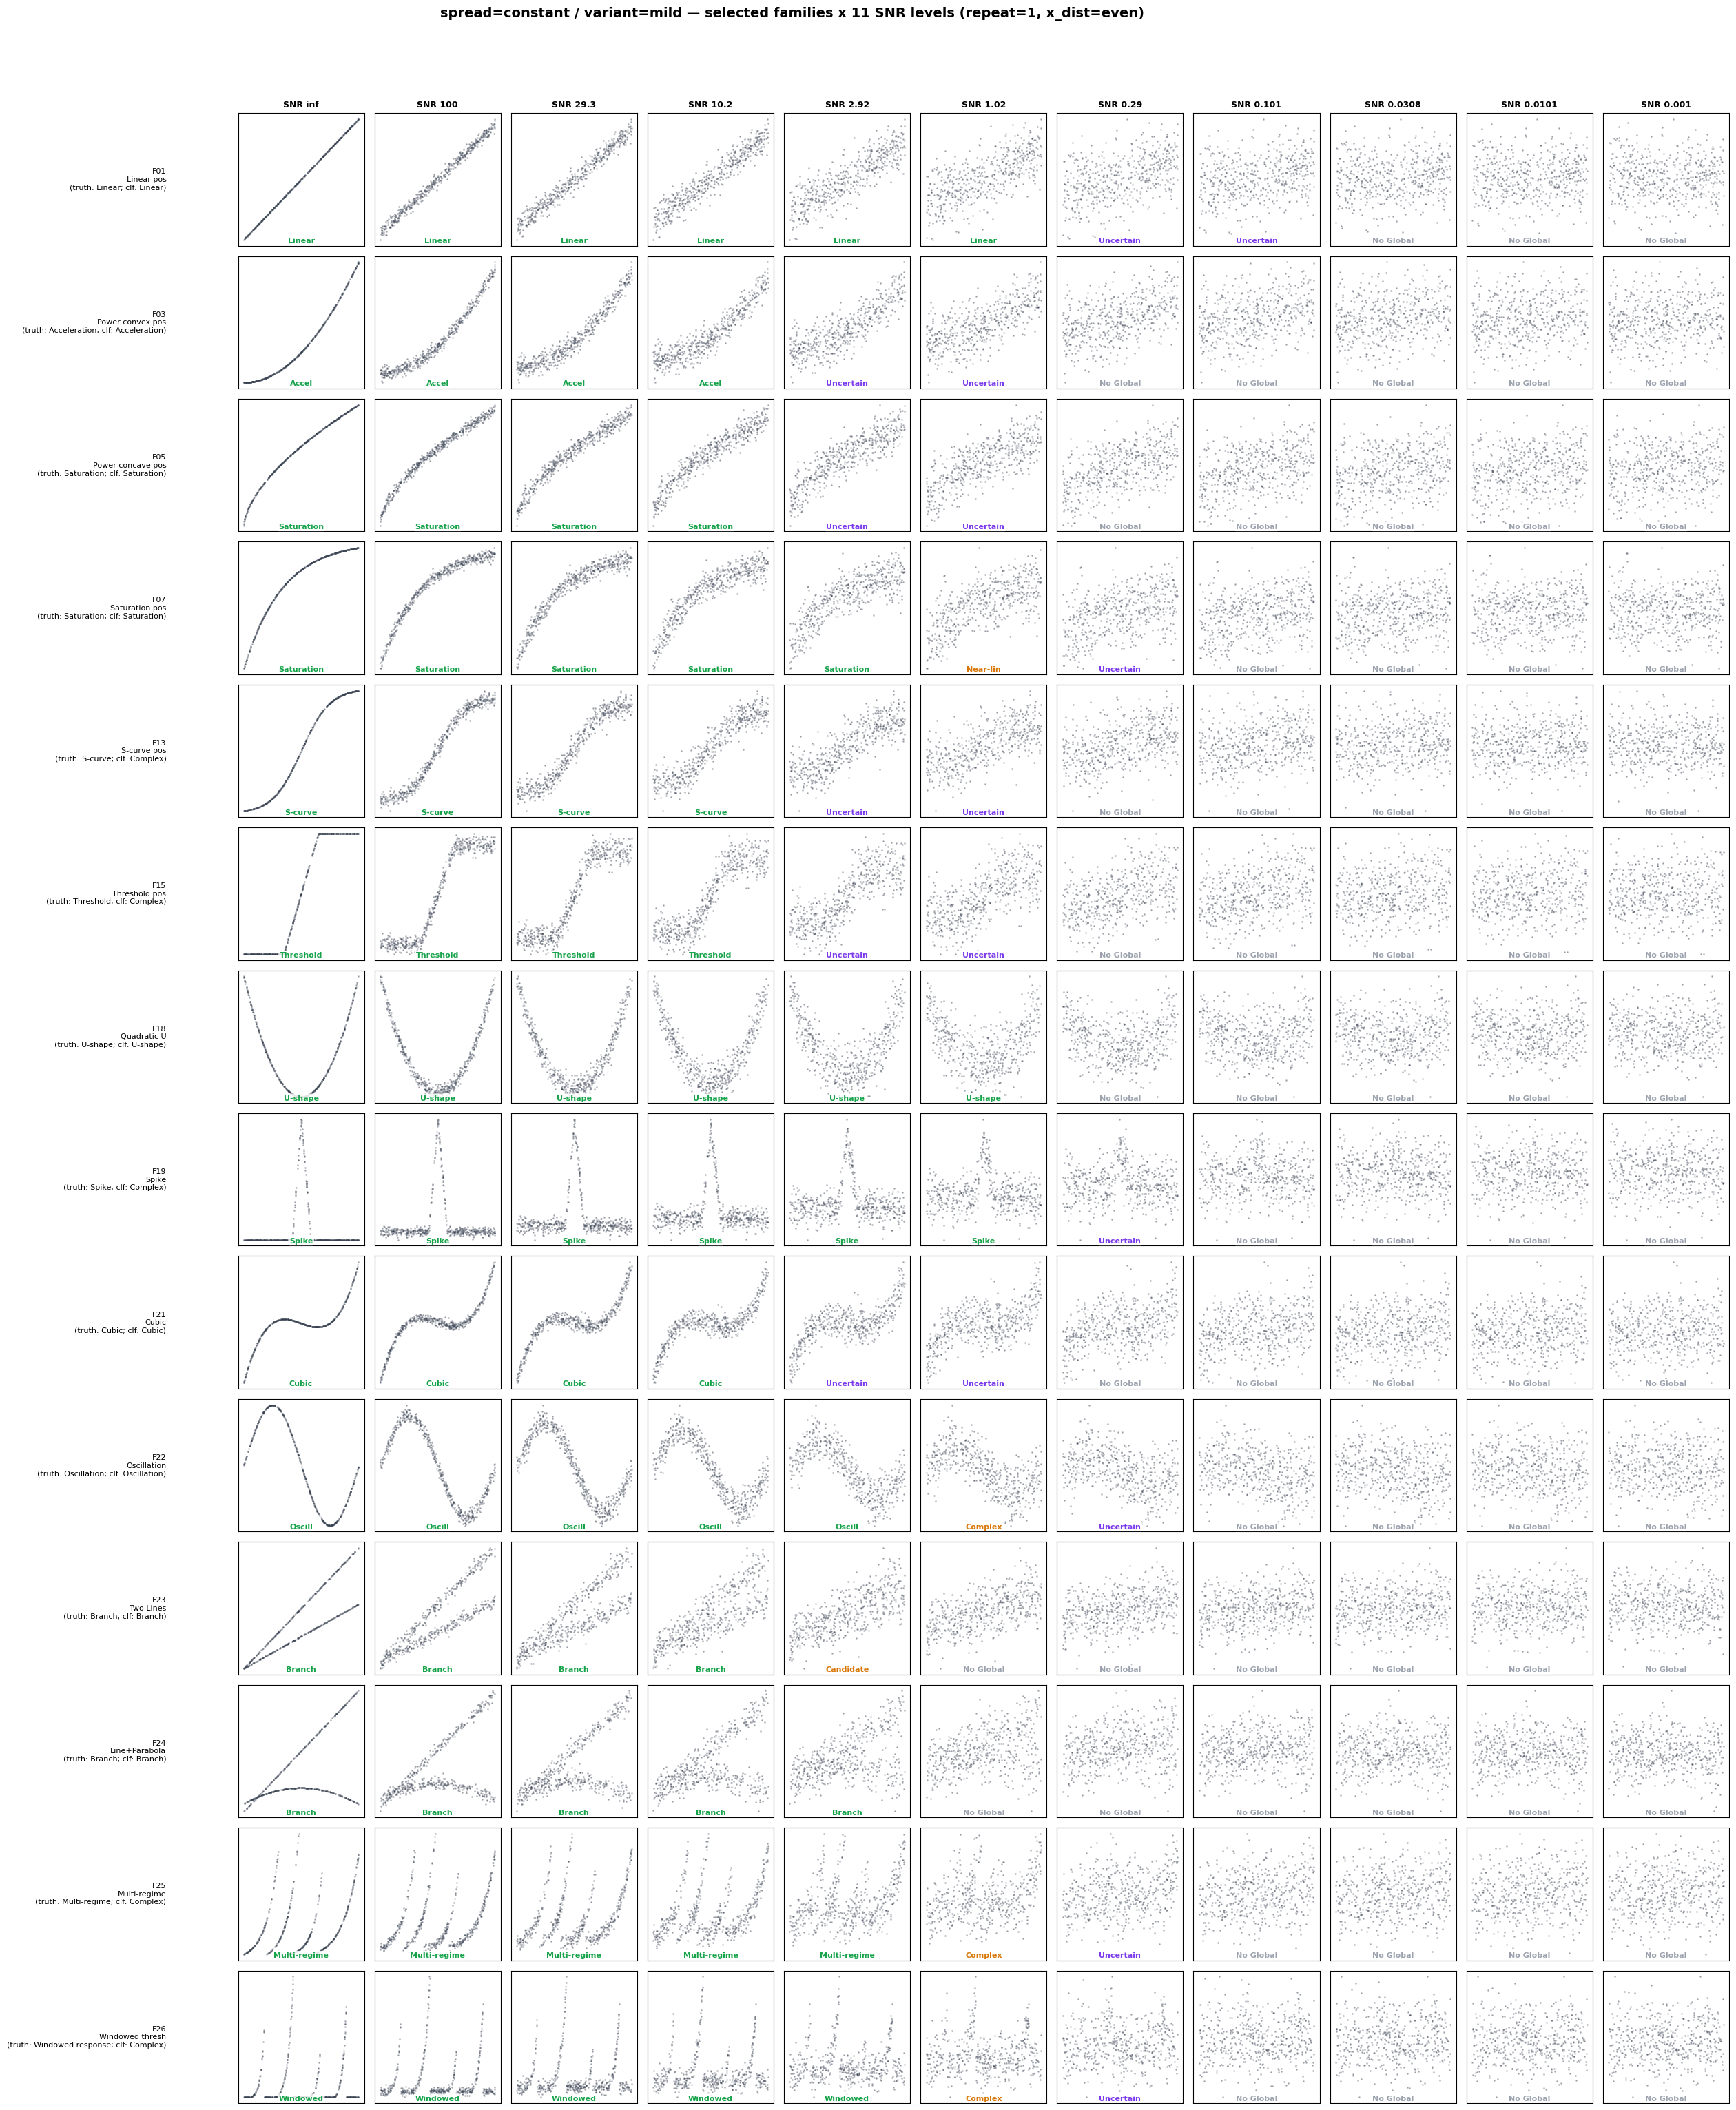

In [4]:
for variant in ['strong', 'standard', 'mild']:
    vdf = cases_df[cases_df['variant_level'] == variant]
    if len(vdf) == 0:
        print(f'No data for variant={variant}')
        continue

    families = sorted([
        f for f in FAMILY_CATALOGUE
        if f != 'Null' and f in vdf['family_id'].unique()
    ])
    n_rows = len(families)
    n_cols = len(DISPLAY_SNRS)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.2 * n_rows),
    )
    fig.suptitle(
        f'spread={SPREAD} / variant={variant} — '
        f'{GROUP} families x {n_cols} SNR levels '
        f'(repeat=1, x_dist={XDIST})',
        fontsize=14, fontweight='bold', y=0.998,
    )

    for i, fid in enumerate(families):
        fdata = vdf[vdf['family_id'] == fid]
        truth = TRUTH_MAP.get(fid, '?')
        classifier_group = CLASSIFIER_GROUP_MAP.get(fid, '?')
        also_ok = ALSO_OK_MAP.get(fid, [])
        fname = FAMILY_CATALOGUE[fid]['name']

        for j, snr in enumerate(DISPLAY_SNRS):
            ax = axes[i, j] if n_rows > 1 else axes[j]
            row = fdata[fdata['nominal_snr'] == snr]

            if i == 0:
                snr_s = 'inf' if np.isinf(snr) else f'{snr:.3g}'
                ax.set_title(f'SNR {snr_s}', fontsize=9, fontweight='bold')

            if j == 0:
                ax.set_ylabel(
                    f'{fid}\n{fname}\n(truth: {truth}; clf: {classifier_group})',
                    fontsize=8, rotation=0, ha='right',
                    va='center', labelpad=75,
                )

            ax.set_xticks([])
            ax.set_yticks([])

            if len(row) == 0:
                ax.text(
                    0.5, 0.5, '—', transform=ax.transAxes,
                    ha='center', va='center', color='#9ca3af',
                )
                continue

            r = row.iloc[0]
            pt_idx = int(r['_pt_idx'])
            xi, yi = x_all[pt_idx], y_all[pt_idx]
            valid = np.isfinite(xi) & np.isfinite(yi)
            ax.scatter(
                xi[valid], yi[valid],
                s=1, alpha=0.3, color='#374151',
            )

            human = get_human_label(fid, snr)
            if human == truth:
                color = '#16a34a'   # green
            elif human in also_ok:
                color = '#d97706'   # amber
            elif human == 'No Global Relationship':
                color = '#9ca3af'   # gray
            elif human == 'Uncertain':
                color = '#7c3aed'   # violet
            else:
                color = '#dc2626'   # red

            ax.text(
                0.5, 0.01, short(human),
                transform=ax.transAxes, ha='center', va='bottom',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(
                    boxstyle='round,pad=0.15',
                    facecolor='white', alpha=0.85,
                    edgecolor='none',
                ),
            )

    plt.tight_layout(rect=[0.08, 0.005, 1, 0.97])
    plt.show()
    print()

## 4 — Annotation summary table

Compact view of human annotations across all SNR levels.

In [5]:
rows = []
for fid in sorted(f for f in FAMILY_CATALOGUE if f != 'Null'):
    truth = TRUTH_MAP[fid]
    classifier_group = CLASSIFIER_GROUP_MAP[fid]
    fname = FAMILY_CATALOGUE[fid]['name']
    row = {'family': fid, 'name': fname, 'truth': truth, 'classifier_group': classifier_group}
    for snr in DISPLAY_SNRS:
        snr_key = 'inf' if np.isinf(snr) else f'{snr:.3g}'
        human = get_human_label(fid, snr)
        if human == truth:
            marker = ' +'
        elif human in ALSO_OK_MAP.get(fid, []):
            marker = ' ~'
        elif human == 'No Global Relationship':
            marker = ''
        elif human == 'Uncertain':
            marker = ' ?'
        else:
            marker = ' !!'
        row[f'SNR {snr_key}'] = short(human) + marker
    rows.append(row)

summary = pd.DataFrame(rows).set_index('family')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 250)
pd.set_option('display.max_colwidth', 25)
display(summary)

print('\nLegend: + = matches family truth, ~ = acceptable visible alternative, ? = uncertain, !! = different from truth')

,name,truth,classifier_group,SNR inf,SNR 100,SNR 29.3,SNR 10.2,SNR 2.92,SNR 1.02,SNR 0.29,SNR 0.101,SNR 0.0308,SNR 0.0101,SNR 0.001
family,,,,,,,,,,,,,,
F01,Linear pos,Linear,Linear,Linear +,Linear +,Linear +,Linear +,Linear +,Linear +,Uncertain ?,Uncertain ?,No Global,No Global,No Global
F03,Power convex pos,Acceleration,Acceleration,Accel +,Accel +,Accel +,Accel +,Uncertain ?,Uncertain ?,No Global,No Global,No Global,No Global,No Global
F05,Power concave pos,Saturation,Saturation,Saturation +,Saturation +,Saturation +,Saturation +,Uncertain ?,Uncertain ?,No Global,No Global,No Global,No Global,No Global
F07,Saturation pos,Saturation,Saturation,Saturation +,Saturation +,Saturation +,Saturation +,Saturation +,Near-lin ~,Uncertain ?,No Global,No Global,No Global,No Global
F13,S-curve pos,S-curve,Complex,S-curve +,S-curve +,S-curve +,S-curve +,Uncertain ?,Uncertain ?,No Global,No Global,No Global,No Global,No Global
F15,Threshold pos,Threshold,Complex,Threshold +,Threshold +,Threshold +,Threshold +,Uncertain ?,Uncertain ?,No Global,No Global,No Global,No Global,No Global
F18,Quadratic U,U-shape,U-shape,U-shape +,U-shape +,U-shape +,U-shape +,U-shape +,U-shape +,No Global,No Global,No Global,No Global,No Global
F19,Spike,Spike,Complex,Spike +,Spike +,Spike +,Spike +,Spike +,Spike +,Uncertain ?,No Global,No Global,No Global,No Global
F21,Cubic,Cubic,Cubic,Cubic +,Cubic +,Cubic +,Cubic +,Uncertain ?,Uncertain ?,No Global,No Global,No Global,No Global,No Global



Legend: + = matches family truth, ~ = acceptable visible alternative, ? = uncertain, !! = different from truth
